In [1]:
import sys
print(sys.executable)

/home/fabiene/anaconda3/envs/orange3/bin/python



hugging face interference_Client chat

https://huggingface.co/docs/huggingface.js/inference/classes/InferenceClient


huggingface_hub.InterferenceClient


InterferenceClient.chat_completion


https://huggingface.co/docs/inference-providers/tasks/chat-completion

meu token salvo no arquivo parecido em txt, com nome env

OPENAI_API_KEY=xxxxxxxx

HF_TOKEN=xxxxxxxxxxx


configuração da leitura inferenceClient

In [3]:
def buscar_token(arquivo):
    with open(arquivo, 'r') as f:
        for linha in f:
            if 'HF_TOKEN' in linha:
                # Divide no '=' e remove espaços ou quebras de linha
                return linha.split('=')[1].strip()

# Uso:
meu_token = buscar_token('env')
#print(meu_token) # senha token

In [4]:
from huggingface_hub import InferenceClient
from dotenv import load_dotenv

load_dotenv()

True

https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct

In [8]:
# modelo da hugging IA (llama) ou da open ai, 

In [6]:
# leitura do programa
cliente = InferenceClient(model="meta-llama/Llama-3.2-3B-Instruct")

https://huggingface.co/docs/huggingface_hub/package_reference/inference_client

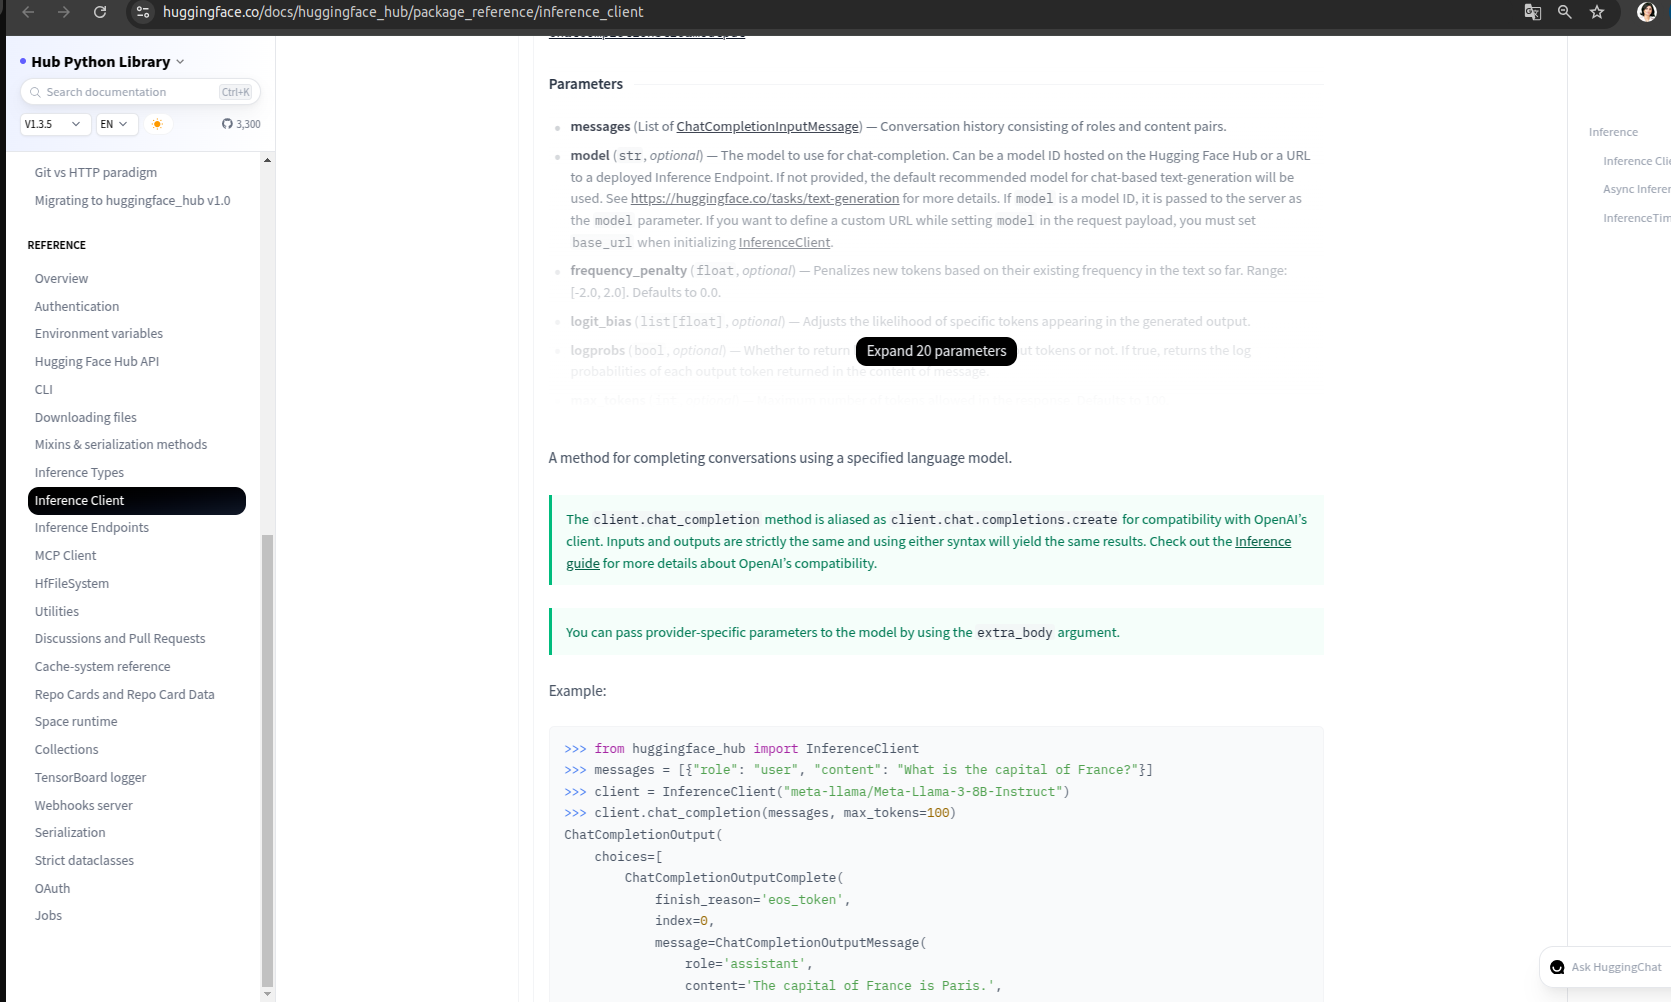

In [7]:
# from huggingface_hub import InferenceClient
# messages = [{"role": "user", "content": "What is the capital of France?"}]
# client = InferenceClient("meta-llama/Meta-Llama-3-8B-Instruct")
# client.chat_completion(messages, max_tokens=100)
# ChatCompletionOutput(
#     choices=[
#         ChatCompletionOutputComplete(
#             finish_reason='eos_token',
#             index=0,
#             message=ChatCompletionOutputMessage(
#                 role='assistant',
#                 content='The capital of France is Paris.',
#                 name=None,
#                 tool_calls=None
#             ),
#             logprobs=None
#         )
#     ],
#     created=1719907176,
#     id='',
#     model='meta-llama/Meta-Llama-3-8B-Instruct',
#     object='text_completion',
#     system_fingerprint='2.0.4-sha-f426a33',
#     usage=ChatCompletionOutputUsage(
#         completion_tokens=8,
#         prompt_tokens=17,
#         total_tokens=25
#     )
# )

In [11]:
# role: quem manda a mensagem
# role: configuração do chat (system), usuário (user), assistent or ia (resposta do sistema)
# parâmetro de conteúdo: content
mensagens = [
    {"role": "system", "content": "Responda as perguntas de forma correta e precisa"},
    #{"role":"user", "content": "O que é Python linguagem de programação?"}
    
]

# modelo que aceita respostas e perguntas em português "meta-llama/Llama-3.2-3B-Instruct"
#cliente = InferenceClient(model="meta-llama/Llama-3.2-3B-Instruct")

## correção: tem que colocar o token no sistema

In [16]:
cliente = InferenceClient(token=meu_token, model="meta-llama/Llama-3.2-3B-Instruct")


In [17]:
mensagem_usuario =  {"role":"user", "content": "O que é Python linguagem de programação?"}

In [18]:
# criando um chat ou interação
mensagens.append(mensagem_usuario)

In [19]:
mensagens

[{'role': 'system',
  'content': 'Responda as perguntas de forma correta e precisa'},
 {'role': 'user', 'content': 'O que é Python linguagem de programação?'},
 {'role': 'user', 'content': 'O que é Python linguagem de programação?'}]

In [20]:

# criando uma resposta direta
# o chat_completion recebe uma lista na forma de dicionário
resposta = cliente.chat_completion(mensagens)

In [21]:
print(resposta)

ChatCompletionOutput(choices=[ChatCompletionOutputComplete(finish_reason='stop', index=0, message=ChatCompletionOutputMessage(role='assistant', content='**O que é Python?**\n\nPython é uma linguagem de programação de alto nível, interpretada e de script, desenvolvida por Guido van Rossum em anos 1980. É uma das linguagens de programação mais populares e amplamente utilizadas no mundo, conhecida por sua simplicidade, flexibilidade e facilidade de aprendizado.\n\n**Características principais de Python:**\n\n- **Interpretada:** Não é compilada em código máquina antes de ser executada. Isso significa que os programadores podem escrever e executar o código diretamente sem precisar da ajuda de um compilador.\n- **Linguagem de alto nível:** Oferece uma grande flexibilidade em termos de estrutura de dados e operações, tornando-a ideal para uma ampla variedade de aplicações.\n- **Scripting:** Permite que os programadores escrevam scripts para automatizar tarefas e processos.\n- **Extensa biblio

há várias choices

In [23]:
from pprint import pprint

pprint(resposta)

ChatCompletionOutput(choices=[ChatCompletionOutputComplete(finish_reason='stop', index=0, message=ChatCompletionOutputMessage(role='assistant', content='**O que é Python?**\n\nPython é uma linguagem de programação de alto nível, interpretada e de script, desenvolvida por Guido van Rossum em anos 1980. É uma das linguagens de programação mais populares e amplamente utilizadas no mundo, conhecida por sua simplicidade, flexibilidade e facilidade de aprendizado.\n\n**Características principais de Python:**\n\n- **Interpretada:** Não é compilada em código máquina antes de ser executada. Isso significa que os programadores podem escrever e executar o código diretamente sem precisar da ajuda de um compilador.\n- **Linguagem de alto nível:** Oferece uma grande flexibilidade em termos de estrutura de dados e operações, tornando-a ideal para uma ampla variedade de aplicações.\n- **Scripting:** Permite que os programadores escrevam scripts para automatizar tarefas e processos.\n- **Extensa biblio

### melhor visualização

In [25]:
# Acessando o conteúdo da mensagem diretamente
print(resposta.choices[0].message.content)

**O que é Python?**

Python é uma linguagem de programação de alto nível, interpretada e de script, desenvolvida por Guido van Rossum em anos 1980. É uma das linguagens de programação mais populares e amplamente utilizadas no mundo, conhecida por sua simplicidade, flexibilidade e facilidade de aprendizado.

**Características principais de Python:**

- **Interpretada:** Não é compilada em código máquina antes de ser executada. Isso significa que os programadores podem escrever e executar o código diretamente sem precisar da ajuda de um compilador.
- **Linguagem de alto nível:** Oferece uma grande flexibilidade em termos de estrutura de dados e operações, tornando-a ideal para uma ampla variedade de aplicações.
- **Scripting:** Permite que os programadores escrevam scripts para automatizar tarefas e processos.
- **Extensa biblioteca:** Disponível uma ampla gama de bibliotecas e módulos que permitem que os programadores realizem tarefas complexas, como análise de dados, processamento de l

In [27]:
# from IPython.display import display, HTML

# # Exibir como HTML renderizado
# display(HTML(resposta))

In [29]:
#resposta.choices, sendo o choices a opção de resposta

In [30]:
print(resposta.choices)

[ChatCompletionOutputComplete(finish_reason='stop', index=0, message=ChatCompletionOutputMessage(role='assistant', content='**O que é Python?**\n\nPython é uma linguagem de programação de alto nível, interpretada e de script, desenvolvida por Guido van Rossum em anos 1980. É uma das linguagens de programação mais populares e amplamente utilizadas no mundo, conhecida por sua simplicidade, flexibilidade e facilidade de aprendizado.\n\n**Características principais de Python:**\n\n- **Interpretada:** Não é compilada em código máquina antes de ser executada. Isso significa que os programadores podem escrever e executar o código diretamente sem precisar da ajuda de um compilador.\n- **Linguagem de alto nível:** Oferece uma grande flexibilidade em termos de estrutura de dados e operações, tornando-a ideal para uma ampla variedade de aplicações.\n- **Scripting:** Permite que os programadores escrevam scripts para automatizar tarefas e processos.\n- **Extensa biblioteca:** Disponível uma ampla 

In [31]:
print(resposta.choices[0])

ChatCompletionOutputComplete(finish_reason='stop', index=0, message=ChatCompletionOutputMessage(role='assistant', content='**O que é Python?**\n\nPython é uma linguagem de programação de alto nível, interpretada e de script, desenvolvida por Guido van Rossum em anos 1980. É uma das linguagens de programação mais populares e amplamente utilizadas no mundo, conhecida por sua simplicidade, flexibilidade e facilidade de aprendizado.\n\n**Características principais de Python:**\n\n- **Interpretada:** Não é compilada em código máquina antes de ser executada. Isso significa que os programadores podem escrever e executar o código diretamente sem precisar da ajuda de um compilador.\n- **Linguagem de alto nível:** Oferece uma grande flexibilidade em termos de estrutura de dados e operações, tornando-a ideal para uma ampla variedade de aplicações.\n- **Scripting:** Permite que os programadores escrevam scripts para automatizar tarefas e processos.\n- **Extensa biblioteca:** Disponível uma ampla g

In [33]:
# otimizar a resposta
resposta_ia = resposta.choices[0]

In [37]:
# quero a role do sistema
role_resposta = resposta_ia.message.role
print(role_resposta)

assistant


In [36]:
# resposta
content_resposta = resposta_ia.message.content
print(content_resposta)

**O que é Python?**

Python é uma linguagem de programação de alto nível, interpretada e de script, desenvolvida por Guido van Rossum em anos 1980. É uma das linguagens de programação mais populares e amplamente utilizadas no mundo, conhecida por sua simplicidade, flexibilidade e facilidade de aprendizado.

**Características principais de Python:**

- **Interpretada:** Não é compilada em código máquina antes de ser executada. Isso significa que os programadores podem escrever e executar o código diretamente sem precisar da ajuda de um compilador.
- **Linguagem de alto nível:** Oferece uma grande flexibilidade em termos de estrutura de dados e operações, tornando-a ideal para uma ampla variedade de aplicações.
- **Scripting:** Permite que os programadores escrevam scripts para automatizar tarefas e processos.
- **Extensa biblioteca:** Disponível uma ampla gama de bibliotecas e módulos que permitem que os programadores realizem tarefas complexas, como análise de dados, processamento de l

In [38]:
# criando o dicionário da resposta 
dicionario_resposta_ia = {"role": role_resposta, "content": content_resposta}
dicionario_resposta_ia

{'role': 'assistant',
 'content': '**O que é Python?**\n\nPython é uma linguagem de programação de alto nível, interpretada e de script, desenvolvida por Guido van Rossum em anos 1980. É uma das linguagens de programação mais populares e amplamente utilizadas no mundo, conhecida por sua simplicidade, flexibilidade e facilidade de aprendizado.\n\n**Características principais de Python:**\n\n- **Interpretada:** Não é compilada em código máquina antes de ser executada. Isso significa que os programadores podem escrever e executar o código diretamente sem precisar da ajuda de um compilador.\n- **Linguagem de alto nível:** Oferece uma grande flexibilidade em termos de estrutura de dados e operações, tornando-a ideal para uma ampla variedade de aplicações.\n- **Scripting:** Permite que os programadores escrevam scripts para automatizar tarefas e processos.\n- **Extensa biblioteca:** Disponível uma ampla gama de bibliotecas e módulos que permitem que os programadores realizem tarefas complexa

In [40]:
# isso tudo para criar novas mensagens pela ia, por isso o dicionário

## segundo teste 

In [41]:
pegunta2= [{'role': 'system',
  'content': 'Responda as perguntas de forma correta e precisa'},
 {'role': 'user', 'content': 'O que é Turma da Mônica?'},
          ]

In [42]:
# o chat_completion recebe uma lista na forma de dicionário
resposta_teste2 = cliente.chat_completion(pegunta2)

In [43]:
resposta_teste2

ChatCompletionOutput(choices=[ChatCompletionOutputComplete(finish_reason='stop', index=0, message=ChatCompletionOutputMessage(role='assistant', content='A Turma da Mônica é uma das séries de quadrinhos mais conhecidas e amadas do Brasil. Criada pelo desenhistas Milton C. Rodrigues, Edgar P. Cesar e Mônica (assim chamada, mas que não é uma personagem da história), ela foi lançada pela Editora Abril em 1959 e rapidamente se tornou um sucesso nacional.\n\nA série segue a aventura de uma turma de amigos, liderados pela personagem Mônica, que vivem em uma fazenda no interior do Brasil. Eles são conhecidos por suas aventuras, brigas e brigadas, mas também por suas amizades e solidariedade.\n\nA Turma da Mônica é conhecida por ser uma das primeiras séries de quadrinhos a retratar uma turma de amigos com personalidades diferentes, e por ser uma das primeiras a usar o linguajar coloquial e as expressões populares da época. Ela também é conhecida por suas histórias mais maduras e complexas, que 

In [44]:
# Acessando o conteúdo da mensagem diretamente
print(resposta_teste2.choices[0].message.content)

A Turma da Mônica é uma das séries de quadrinhos mais conhecidas e amadas do Brasil. Criada pelo desenhistas Milton C. Rodrigues, Edgar P. Cesar e Mônica (assim chamada, mas que não é uma personagem da história), ela foi lançada pela Editora Abril em 1959 e rapidamente se tornou um sucesso nacional.

A série segue a aventura de uma turma de amigos, liderados pela personagem Mônica, que vivem em uma fazenda no interior do Brasil. Eles são conhecidos por suas aventuras, brigas e brigadas, mas também por suas amizades e solidariedade.

A Turma da Mônica é conhecida por ser uma das primeiras séries de quadrinhos a retratar uma turma de amigos com personalidades diferentes, e por ser uma das primeiras a usar o linguajar coloquial e as expressões populares da época. Ela também é conhecida por suas histórias mais maduras e complexas, que exploram temas como a amizade, a solidariedade, a natureza e a relação entre os seres humanos.

A Turma da Mônica é considerada uma das mais importantes e in